In [52]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from finvizfinance.quote import finvizfinance

import warnings
warnings.filterwarnings("ignore")

import os

In [53]:
# directory path
dir_path = r"..\14_stocks_analysis\00_data"
if not os.path.isdir(dir_path):
    raise FileNotFoundError(f'Directory does not exist: {dir_path}')
print(f'Using data directory: {dir_path}')

Using data directory: ..\14_stocks_analysis\00_data


In [54]:
# concatenate all tabular files into a single dataframe
files = [
    file for file in os.listdir(dir_path)
    if file.lower().endswith(('.csv', '.xlsx', '.xls'))
]
if not files:
    raise ValueError(f'No CSV/XLSX/XLS files found in: {dir_path}')

def load_table(file_name):
    file_path = os.path.join(dir_path, file_name)
    if file_name.lower().endswith('.csv'):
        return pd.read_csv(file_path)
    return pd.read_excel(file_path)

# file name have format like 2603, 2602..first two digits are year and last two are month
# when concatenating, we need to add a column with the date extracted from the file name
def extract_date(file_name):
    year = int(file_name[:2]) + 2000
    month = int(file_name[2:4])
    return pd.Timestamp(year=year, month=month, day=1)

df = pd.concat([load_table(file).assign(date=extract_date(file)) for file in sorted(files)], ignore_index=True)

# lowercase column names
df.columns = df.columns.str.lower()

# replace " " with "_" in column names
df.columns = df.columns.str.replace(" ", "_")

df.head()

,unnamed:_0,symbol,stock,market_cap,price,fair_value_(%),z-score,f-score,m-score,value_generation,date
0,1.0,Lululemon Athletica Inc.,Lululemon Athletica Inc.,20.11B,168.18,116.31,7.43,8.0,-2.78,Robust,2025-11-01
1,NaN,LULU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-01
2,2.0,"PayPal Holdings, Inc.","PayPal Holdings, Inc.",58.63B,60.57,100.92,1.96,7.0,-2.99,Robust,2025-11-01
3,NaN,PYPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-01
4,3.0,Adobe Inc.,Adobe Inc.,139.08B,324.19,82.13,8.92,7.0,-2.49,Robust,2025-11-01


In [55]:
# create a copy of symbol column named 'symbol_copy'
df['symbol_copy'] = df['symbol']

In [56]:
# the series in df.symbol_copy, should be shifted backwards by 1 row, to align with the stock name in the same row
df['symbol_copy'] = df['symbol_copy'].shift(-1)

In [57]:
# drop nan in df.unnamed:_0
df = df.dropna(subset=['unnamed:_0'])

In [58]:
# drop columns 'unnamed: 0', 'symbol'
df = df.drop(columns=['unnamed:_0', 'symbol'])

# rename column 'symbol_copy' to 'symbol'
df = df.rename(columns={'symbol_copy': 'symbol'})

# columns order 'date', 'symbol', 'stock', 'market cap', 'price', 'fair value (%)', 'z-score', 'f-score', 'm-score', 'value generation'
df = df[['date', 'symbol', 'stock', 'market_cap', 'price', 'fair_value_(%)', 'z-score', 'f-score', 'm-score', 'value_generation']]

In [59]:
df.columns

Index(['date', 'symbol', 'stock', 'market_cap', 'price', 'fair_value_(%)',
       'z-score', 'f-score', 'm-score', 'value_generation'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 498
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              250 non-null    datetime64[us]
 1   symbol            250 non-null    object        
 2   stock             250 non-null    object        
 3   market_cap        250 non-null    object        
 4   price             250 non-null    float64       
 5   fair_value_(%)    250 non-null    float64       
 6   z-score           250 non-null    float64       
 7   f-score           250 non-null    object        
 8   m-score           250 non-null    float64       
 9   value_generation  250 non-null    object        
dtypes: datetime64[us](1), float64(4), object(5)
memory usage: 21.5+ KB


In [61]:
# create a copy of the dataframe
df_copy = df.copy()

# keep only date, symbol columns
df_copy = df_copy[['date', 'symbol']]

# group by symbol and count the number of occurrences of each symbol
symbol_counts = df_copy.groupby('symbol').size().reset_index(name='count')

# sort the dataframe by count in descending order
symbol_counts = symbol_counts.sort_values(by='count', ascending=False)

# display the top 10 symbols with the most occurrences
print(symbol_counts.head(10))

   symbol  count
2    ADBE      5
18    CLX      5
41   FTNT      5
93   PYPL      5
20    CMG      4
7     AVY      4
17     CL      4
35     EW      4
50    HUM      4
25   DECK      4


In [62]:
# drop duplicates in df.symbol, keep last occurrence
df = df.drop_duplicates(subset='symbol', keep='last')

# merge df with symbol_counts on symbol, keeping only rows that are in df
df = df.merge(symbol_counts, on='symbol', how='inner')

# sort df by count in descending order
df = df.sort_values(by='count', ascending=False)

df.head(10)

,date,symbol,stock,market_cap,price,fair_value_(%),z-score,f-score,m-score,value_generation,count
83,2026-03-01,PYPL,"PayPal Holdings, Inc.",42.66B,444859.00,87.65,1.99,8.0,-2.54,Robust,5
72,2026-03-01,CLX,The Clorox Company,12.44B,102.28,87.39,2.44,6.0,-3.16,Robust,5
69,2026-03-01,ADBE,Adobe Inc.,98.74B,2408252.00,101.55,7.53,7.0,-3.41,Robust,5
117,2026-03-01,FTNT,"Fortinet, Inc.",59.24B,79725.00,17.65,5.22,7.0,-2.23,Robust,5
39,2026-02-01,CMG,"Chipotle Mexican Grill, Inc.",48.27B,36.71,50.78,7.74,8.0,-1.70,Robust,4
42,2026-02-01,AVY,Avery Dennison Corporation,14.49B,187.20,29.80,3.93,9.0,-2.89,Robust,4
41,2026-02-01,DECK,Deckers Outdoor Corporation,15.98B,108.74,33.70,14.21,9.0,-2.89,Robust,4
55,2026-02-01,TMO,Thermo Fisher Scientific Inc.,192.77B,512.69,12.11,4.07,8.0,-2.65,Robust,4
66,2026-02-01,JKHY,"Jack Henry & Associates, Inc.",12.20B,168.43,23.66,10.78,8.0,-2.31,Resilient,4
74,2026-03-01,LDOS,"Leidos Holdings, Inc.",20.35B,153.66,78.00,4.15,8.0,-2.51,Robust,4


In [63]:
# market cap column is object. We need to convert it to numeric, removing any non-numeric characters ("T" indicating trillions, 
# "B", indicating billions, "M" indicating millions)
# These characters are at the end of the string, so we can use str.replace to remove them and then convert to numeric
# They will be added in a new column named 'market cap um'

# take last character of market cap column and add a new column 'market_cap_um' with the value of the last character
df['market_cap_um'] = df['market_cap'].str[-1]

# replace 'T', 'B', 'M' with "" in market cap column and convert to numeric
df['market_cap'] = df['market_cap'].str.replace(r'[TBM]', '', regex=True).astype(float)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, 83 to 118
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              119 non-null    datetime64[us]
 1   symbol            119 non-null    object        
 2   stock             119 non-null    object        
 3   market_cap        119 non-null    float64       
 4   price             119 non-null    float64       
 5   fair_value_(%)    119 non-null    float64       
 6   z-score           119 non-null    float64       
 7   f-score           119 non-null    object        
 8   m-score           119 non-null    float64       
 9   value_generation  119 non-null    object        
 10  count             119 non-null    int64         
 11  market_cap_um     119 non-null    object        
dtypes: datetime64[us](1), float64(5), int64(1), object(5)
memory usage: 12.1+ KB


In [65]:
# if market cap um is M, market cap / 1000, if market cap um is T, market cap * 1000, if market cap um is B, market cap / 1
def convert_market_cap(row):
    if row['market_cap_um'] == 'M':
        return row['market_cap'] / 1000
    elif row['market_cap_um'] == 'T':
        return row['market_cap'] * 1000
    elif row['market_cap_um'] == 'B':
        return row['market_cap']
    else:
        return row['market_cap']

# apply the function to the dataframe and create a new column 'market_cap_converted'
df['market_cap_converted'] = df.apply(convert_market_cap, axis=1)

In [66]:
# drop market cap	
df = df.drop(columns=['market_cap'])

# rename market cap converted to market cap
df = df.rename(columns={'market_cap_converted': 'market_cap'})

# columns order 'date', 'symbol', 'stock', 'price', 'fair value (%)', 'z-score', 'f-score', 'm-score', 'value generation', 'market cap um', 'market cap'
df = df[['date', 'symbol', 'stock', 'price', 'fair_value_(%)', 'z-score', 
'f-score', 'm-score', 'value_generation', 'market_cap_um', 'market_cap', 'count']]


In [67]:
# --- market cap filter ---
# drop all rows where market cap um is M
df = df[df['market_cap_um'] != 'M']

# drop all rows where market cap um is B and market cap is less than 10
df = df[~((df['market_cap_um'] == 'B') & (df['market_cap'] < 10))]

# rename df.market_cap to market_cap_(B)
df = df.rename(columns={'market_cap': 'market_cap_(B)'})

# drop market_cap_um
df = df.drop(columns=['market_cap_um'])

In [68]:
# add currency column according to the stock exchange where the stock is listed. Need to identify currency based on df.symbol 
# ends with:
# .MI -> EUR
# .DE -> EUR
# .PA -> EUR
# .L -> GBP
# .T -> JPY
# .AX -> AUD
# .SR -> SAR
# .HK -> HKD
# .TO -> CAD
# .NZ -> NZD
# .KL -> MYR
# .MX -> MXN
# if df.symbol does not contain ".", add USD as currency
# if none of the above conditions are met, currency 
def identify_currency(symbol):
    if symbol.endswith('.MI') or symbol.endswith('.DE') or symbol.endswith('.PA'):
        return 'EUR'
    elif symbol.endswith('.L'):
        return 'GBP'
    elif symbol.endswith('.T'):
        return 'JPY'
    elif symbol.endswith('.AX'):
        return 'AUD'
    elif symbol.endswith('.SR'):
        return 'SAR'
    elif symbol.endswith('.HK'):
        return 'HKD'
    elif symbol.endswith('.TO'):
        return 'CAD'
    elif symbol.endswith('.NZ'):
        return 'NZD'
    elif symbol.endswith('.KL'):
        return 'MYR'
    elif symbol.endswith('.MX'):
        return 'MXN'
    elif '.' not in symbol:
        return 'USD'
    else:
        return 'Unknown'
    
# apply the function to the dataframe and create a new column 'currency'
df['currency'] = df['symbol'].apply(identify_currency)

In [69]:
# print Unknown symbols in currency column
print(df[df['currency'] == 'Unknown']['symbol'])

Series([], Name: symbol, dtype: object)


In [70]:
# --- currency filter ---
# keep only EUR and USD stocks
df = df[df['currency'].isin(['EUR', 'USD'])]

In [71]:
# --- solidity filter ---
# convert z-score, f-score, m-score to numeric
df['z-score'] = pd.to_numeric(df['z-score'], errors='coerce')
df['f-score'] = pd.to_numeric(df['f-score'], errors='coerce')
df['m-score'] = pd.to_numeric(df['m-score'], errors='coerce')

# drop all rows where z-score is less than 1.81
# drop all rows where f-score is less than 3
# drop all rows where m-score is higher than -1.78
df = df[~((df['z-score'] < 1.81) | (df['f-score'] < 3) | (df['m-score'] > -1.78))]

In [72]:
# --- fair_value_(%) filter ---
# convert fair_value_(%) to numeric
df['fair_value_(%)'] = pd.to_numeric(df['fair_value_(%)'], errors='coerce')

# keep only rows where fair_value_(%) is higher than 0
df = df[df['fair_value_(%)'] > 0]

In [73]:
# list of tickers in the dataframe
tickers = df['symbol'].tolist()

In [74]:
# # TODO: when we have new data, below code can be used to update the fundamentals cache, 
# # by downloading fundamentals for all tickers in the dataframe, 
# # keeping only the keys in keys_to_keep, prefixing the columns with "fv_", 
# # and writing the cache to a CSV file. This way we can keep the fundamentals cache 
# # updated with the latest tickers in the dataframe, 
# # without having to download fundamentals for all tickers every time we run the notebook.

# # batch fundamentals download for all tickers (keeps only keys_to_keep, prefixes columns, writes cache CSV)
# from pathlib import Path
# import re
# import time

# keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)',
# 'Perf Week', 'Forward P/E', 'Perf Month',
# 'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',
# 'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C',
# 'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.',
# 'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM',
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom',
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume',
# 'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

# def normalize_fundament_key(key):
#     clean_key = re.sub(r'[^0-9a-zA-Z]+', '_', key).strip('_').lower()
#     return f'fv_{clean_key}'

# key_to_col = {key: normalize_fundament_key(key) for key in keys_to_keep}
# fundamentals_rows = []
# failed_tickers = []

# for t in tickers:
#     try:
#         stock_obj = finvizfinance(t)
#         stock_fundament = stock_obj.ticker_fundament()
#         row = {'symbol': t}
#         for key in keys_to_keep:
#             row[key_to_col[key]] = stock_fundament.get(key)
#         fundamentals_rows.append(row)
#     except Exception:
#         failed_tickers.append(t)
#     time.sleep(0.25)

# fundamentals_df = pd.DataFrame(fundamentals_rows)

# fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
# fundamentals_cache_path.parent.mkdir(parents=True, exist_ok=True)
# fundamentals_df.to_csv(fundamentals_cache_path, index=False)

# print(f'Fundamentals downloaded for {len(fundamentals_df)} tickers')
# print(f'Fundamentals cache saved to: {fundamentals_cache_path}')

# # failed tickers report
# if failed_tickers:
#     print('Failed tickers:')
#     print(failed_tickers)
# else:
#     print('No failed tickers.')

In [75]:
# load fundamentals from cache CSV (for tests, avoids repeated API calls)
from pathlib import Path

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_df = pd.read_csv(fundamentals_cache_path)

print(f'Loaded fundamentals cache: {fundamentals_cache_path}')
print(f'Rows: {len(fundamentals_df)}')

fundamentals_df.head()

Loaded fundamentals cache: 14_stocks_analysis\fundamentals_cache.csv
Rows: 87


,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_eps_next_y,fv_perf_month,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PYPL,PayPal Holdings Inc,Financial,Credit Services,8.38,5.41,0.31%,7.86,5.77,-3.02%,...,44.63,0.52,-26.57%,23.99M,45.34,"Jul 06, 2015",-4.43% -1.28%,\n\n,"12,723,116",1.59%
1,CLX,Clorox Co,Consumer Defensive,Household & Personal Products,16.53,6.12,-1.02%,14.93,6.77,-13.87%,...,104.24,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%
2,ADBE,Adobe Inc,Technology,Software - Application,14.15,17.17,0.85%,9.20,26.39,-11.06%,...,241.37,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%
3,FTNT,Fortinet Inc,Technology,Software - Infrastructure,34.01,2.43,1.85%,24.97,3.30,-0.31%,...,81.15,0.43,-3.12%,6.82M,82.53,"Nov 18, 2009",9.08% 2.44%,\n\n,"4,137,940",1.70%
4,AVY,Avery Dennison Corp,Consumer Cyclical,Packaging & Containers,19.51,8.79,1.75%,15.15,11.32,-8.40%,...,173.10,1.51,-2.65%,658.40K,171.47,"Jun 20, 1967",2.26% -0.53%,\n\n,"468,164",-0.94%


In [76]:
# merge fundamentals into df on symbol
df = df.merge(fundamentals_df, on='symbol', how='left')

print(f'Merged dataframe rows: {len(df)}')
print(f'Columns after merge: {len(df.columns)}')

df.head()

Merged dataframe rows: 88
Columns after merge: 76


,date,symbol,stock,price,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,2026-03-01,PYPL,"PayPal Holdings, Inc.",444859.00,87.65,1.99,8.0,-2.54,Robust,42.66,...,44.63,0.52,-26.57%,23.99M,45.34,"Jul 06, 2015",-4.43% -1.28%,\n\n,"12,723,116",1.59%
1,2026-03-01,CLX,The Clorox Company,102.28,87.39,2.44,6.0,-3.16,Robust,12.44,...,104.24,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%
2,2026-03-01,ADBE,Adobe Inc.,2408252.00,101.55,7.53,7.0,-3.41,Robust,98.74,...,241.37,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%
3,2026-03-01,FTNT,"Fortinet, Inc.",79725.00,17.65,5.22,7.0,-2.23,Robust,59.24,...,81.15,0.43,-3.12%,6.82M,82.53,"Nov 18, 2009",9.08% 2.44%,\n\n,"4,137,940",1.70%
4,2026-02-01,AVY,Avery Dennison Corporation,187.20,29.80,3.93,9.0,-2.89,Robust,14.49,...,173.10,1.51,-2.65%,658.40K,171.47,"Jun 20, 1967",2.26% -0.53%,\n\n,"468,164",-0.94%


In [77]:
# quick check: tickers used in batch download
tickers[:10]

['PYPL', 'CLX', 'ADBE', 'FTNT', 'AVY', 'DECK', 'TMO', 'JKHY', 'LDOS', 'CL']

In [78]:
# quick check: cached fundamentals columns (prefixed with fv_)
fundamentals_df.columns.tolist()[:20]

['symbol',
 'fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_eps_next_y',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c']

In [79]:
# preview merged fundamentals for first rows
df.filter(regex='^fv_').head()

,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_eps_next_y,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PayPal Holdings Inc,Financial,Credit Services,8.38,5.41,0.31%,7.86,5.77,-3.02%,4.70%,...,44.63,0.52,-26.57%,23.99M,45.34,"Jul 06, 2015",-4.43% -1.28%,\n\n,"12,723,116",1.59%
1,Clorox Co,Consumer Defensive,Household & Personal Products,16.53,6.12,-1.02%,14.93,6.77,-13.87%,6.10%,...,104.24,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%
2,Adobe Inc,Technology,Software - Application,14.15,17.17,0.85%,9.20,26.39,-11.06%,-,...,241.37,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%
3,Fortinet Inc,Technology,Software - Infrastructure,34.01,2.43,1.85%,24.97,3.30,-0.31%,3.13%,...,81.15,0.43,-3.12%,6.82M,82.53,"Nov 18, 2009",9.08% 2.44%,\n\n,"4,137,940",1.70%
4,Avery Dennison Corp,Consumer Cyclical,Packaging & Containers,19.51,8.79,1.75%,15.15,11.32,-8.40%,2.42%,...,173.10,1.51,-2.65%,658.40K,171.47,"Jun 20, 1967",2.26% -0.53%,\n\n,"468,164",-0.94%


In [80]:
# count how many symbols did not receive fundamentals
missing_fv = df['fv_company'].isna().sum() if 'fv_company' in df.columns else None
print('Symbols with missing fundamentals:', missing_fv)

Symbols with missing fundamentals: 1


In [81]:
# # print failed tickers again (separate output cell)
# print(failed_tickers)

In [82]:
# show first 3 rows from fundamentals cache dataframe
fundamentals_df.head(3)

,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_eps_next_y,fv_perf_month,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PYPL,PayPal Holdings Inc,Financial,Credit Services,8.38,5.41,0.31%,7.86,5.77,-3.02%,...,44.63,0.52,-26.57%,23.99M,45.34,"Jul 06, 2015",-4.43% -1.28%,\n\n,"12,723,116",1.59%
1,CLX,Clorox Co,Consumer Defensive,Household & Personal Products,16.53,6.12,-1.02%,14.93,6.77,-13.87%,...,104.24,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%
2,ADBE,Adobe Inc,Technology,Software - Application,14.15,17.17,0.85%,9.20,26.39,-11.06%,...,241.37,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%


In [83]:
# number of prefixed fundamentals columns
len([c for c in fundamentals_df.columns if c.startswith('fv_')])

64

In [84]:
# # all listed keys in stock_fundament
# """
# dict_keys(['Company', 'Sector', 'Industry', 'Country', 'Exchange', 'Index', 'P/E', 'EPS (ttm)', 
# 'Insider Own', 'Shs Outstand', 'Perf Week', 'Market Cap', 'Forward P/E', 'EPS next Y', 'Insider Trans', 'Shs Float', 'Perf Month', 
# 'Enterprise Value', 'PEG', 'EPS next Q', 'Inst Own', 'Short Float', 'Perf Quarter', 'Income', 'P/S', 'EPS this Y', 'Inst Trans', 
# 'Short Ratio', 'Perf Half Y', 'Sales', 'P/B', 'EPS next Y Percentage', 'ROA', 'Short Interest', 'Perf YTD', 'Book/sh', 'P/C', 
# 'EPS next 5Y', 'ROE', '52W High', 'Perf Year', 'Cash/sh', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Gross Margin', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Dividend Ex-Date', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Target Price', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'Employees', 'LT Debt/Eq', 'Earnings', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'Option/Short', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change'])
# """;

# # keys to keep in stock_fundament
# keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)', 
# 'Perf Week', 'Forward P/E', 'EPS next Y', 'Perf Month', 
# 'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',  
# 'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C', 
# 'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

# # TODO: 'Perf Month', 'Perf Quarter', 'Perf YTD', 'Perf Half Y', 'Perf Year', 'Perf 3Y', 'Perf 5Y', 'Perf 10Y' should be converted to numeric, removing the "%" character, 
# # then used as one of the first filters to keep only stocks with negative performance

# # TODO: 'EPS past 3/5Y': '37.29% 8.84%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is
# # TODO: 'Sales past 3/5Y': '7.21% 9.24%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is

# stock_fundament_filtered = {key: stock_fundament[key] for key in keys_to_keep if key in stock_fundament}

# print(stock_fundament_filtered)

In [85]:
# drop columns price because we will keep only fv_price from fundamentals
df = df.drop(columns=['price'])

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 75 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 88 non-null     datetime64[us]
 1   symbol               88 non-null     object        
 2   stock                88 non-null     object        
 3   fair_value_(%)       88 non-null     float64       
 4   z-score              88 non-null     float64       
 5   f-score              87 non-null     float64       
 6   m-score              88 non-null     float64       
 7   value_generation     88 non-null     object        
 8   market_cap_(B)       88 non-null     float64       
 9   count                88 non-null     int64         
 10  currency             88 non-null     object        
 11  fv_company           87 non-null     object        
 12  fv_sector            87 non-null     object        
 13  fv_industry          87 non-null     

In [87]:
# # sample of merged dataframe with selected fundamentals
# cols_to_show = [c for c in ['symbol', 'stock', 'fv_company', 'fv_sector', 'fv_industry', 'fv_p_e', 'fv_roe', 'fv_profit_margin'] if c in df.columns]
# df[cols_to_show].head(10)

In [88]:
# # rows in merge where at least one fundamentals value exists
# fv_cols = [c for c in df.columns if c.startswith('fv_')]
# df[df[fv_cols].notna().any(axis=1)].head() if fv_cols else df.head()

In [89]:
# list prefixed fundamentals columns
[c for c in df.columns if c.startswith('fv_')]

['fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_eps_next_y',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c',
 'fv_roe',
 'fv_52w_high',
 'fv_perf_year',
 'fv_p_fcf',
 'fv_eps_past_3_5y',
 'fv_roic',
 'fv_52w_low',
 'fv_perf_3y',
 'fv_dividend_est',
 'fv_ev_ebitda',
 'fv_sales_past_3_5y',
 'fv_volatility_w',
 'fv_volatility_m',
 'fv_perf_5y',
 'fv_dividend_ttm',
 'fv_ev_sales',
 'fv_eps_y_y_ttm',
 'fv_oper_margin',
 'fv_atr_14',
 'fv_perf_10y',
 'fv_quick_ratio',
 'fv_sales_y_y_ttm',
 'fv_profit_margin',
 'fv_rsi_14',
 'fv_recom',
 'fv_dividend_gr_3_5y',
 'fv_current_ratio',
 'fv_eps_q_q',
 'fv_sma20',
 'fv_beta',
 'fv_payout',
 'fv_debt_eq',
 'fv_sales_q_q',
 'fv_sma50',
 'fv_rel_volume',
 'fv_prev_close',
 'fv_lt_debt_eq',
 'fv_sma200',
 'fv_avg_volume',
 'fv_price',
 'fv_ipo',
 'fv_eps_sales_surpr'

In [90]:
# select all columns that start with "fv_perf_"
perf_cols = [c for c in df.columns if c.startswith('fv_perf_')]

# convert fv_perf_ columns to numeric, removing the "%" character
for col in perf_cols:
    df[col] = pd.to_numeric(df[col].str.replace('%', ''), errors='coerce')

df[perf_cols].head() if perf_cols else df.head()

,fv_perf_week,fv_perf_month,fv_perf_quarter,fv_perf_half_y,fv_perf_ytd,fv_perf_year,fv_perf_3y,fv_perf_5y,fv_perf_10y
0,0.31,-3.02,-22.34,-31.98,-22.34,-32.48,-40.29,-81.68,15.08
1,-1.02,-13.87,0.31,-17.56,0.31,-31.49,-36.08,-47.55,-20.60
2,0.85,-11.06,-30.59,-29.33,-30.59,-37.03,-36.96,-49.74,155.28
3,1.85,-0.31,3.93,-3.11,3.93,-15.85,24.18,121.39,1231.13
4,1.75,-8.40,-5.72,5.53,-5.72,-5.04,-4.17,-8.83,135.34


In [91]:
# --- performance filters ---
# keep only rows where one of the performance columns is lower than -20
df = df[df[perf_cols].lt(-20).any(axis=1)]

In [92]:
# list of symbols in the final dataframe
final_symbols = df['symbol'].tolist()
# final_symbols

In [93]:
# TODO: uncomment below code to download historical data for the final symbols, and save it to a CSV file. This way we can have the historical data for the selected stocks, and we can use it in the next steps of the analysis.
# # Download historical data from yf API
# data = yf.download(final_symbols, group_by='ticker', period='max')

# # download data to csv
# data.to_csv("final_symbols.csv")

In [94]:
# Load the CSV with MultiIndex columns (Tickers, OHLCV)
data = pd.read_csv("final_symbols.csv", header=[0,1], index_col=0)

# Drop any rows that are completely NaN (e.g. 'Date' row)
data = data.dropna(how='all')

# Convert all values to float
data = data.astype(float)

# Show the result
data.head()

Ticker     OTIS                        ZTS                        ... BF-B  \
Price      Open High Low Close Volume Open High Low Close Volume  ... Open   
Date                                                              ...        
1973-02-21  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1973-02-22  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1973-02-23  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1973-02-26  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1973-02-27  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   

Ticker                                 CLX                                \
Price      High Low Close Volume      Open      High       Low     Close   
Date                                                                       
1973-02-21  NaN NaN   NaN    NaN  1.569869  1.628346  1.569869  1.592360   
1973-02-22  NaN NaN   NaN    NaN  1.587862  1.587862  1.565371  1.565371   
1973-02-23  NaN NaN   NaN    NaN  1.565371  1.583364  1.556375  1.574368   
1973-02-26  NaN NaN   NaN    NaN  1.560873  1.560873  1.515891  1.547379   
1973-02-27  NaN NaN   NaN    NaN  1.547378  1.556374  1.394439  1.398938   

Ticker                
Price         Volume  
Date                  
1973-02-21  115200.0  
1973-02-22  178400.0  
1973-02-23   75200.0  
1973-02-26  157600.0  
1973-02-27  248800.0  

[5 rows x 175 columns]

In [95]:
from market_profile import MarketProfile

# calculate POC price for each ticker in final_symbols
poc = {}
# market_profiles = {} # need to store the market profile objects for later use in the notebook (plotting, etc.) 

for ticker in final_symbols:
    try:
        ticker_data = data[ticker].dropna()
        if ticker_data.empty:
            print(f"No data available for {ticker}.")
            continue

        mp = MarketProfile(ticker_data)
        mp_slice = mp[ticker_data.index.min():ticker_data.index.max()]
        # market_profiles[ticker] = mp_slice

        # Different versions can expose POC differently; handle common cases
        if hasattr(mp_slice, 'poc_price'):
            poc[ticker] = mp_slice.poc_price
        # elif hasattr(mp_slice, 'profile') and 'POC' in mp_slice.profile:
        #     poc[ticker] = mp_slice.profile['POC']
        # elif hasattr(mp_slice, '__getitem__'):
        #     try:
        #         poc[ticker] = mp_slice['POC']
        #     except Exception:
        #         poc[ticker] = None
        else:
            poc[ticker] = None

    except KeyError:
        print(f"Data for {ticker} not found in the dataset.")

In [96]:
# poc dict to dataframe
poc_df = pd.DataFrame.from_dict(poc, orient='index', columns=['poc_price']).reset_index().rename(columns={'index': 'symbol'})

poc_df.head()

,symbol,poc_price
0,PYPL,72.65
1,CLX,0.40
2,ADBE,5.20
3,ZTS,27.95
4,ALGN,11.60


In [97]:
# merge poc_df with df on symbol
df = df.merge(poc_df, on='symbol', how='left')

df.head()

,date,symbol,stock,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),count,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,2026-03-01,PYPL,"PayPal Holdings, Inc.",87.65,1.99,8.0,-2.54,Robust,42.66,5,...,0.52,-26.57%,23.99M,45.34,"Jul 06, 2015",-4.43% -1.28%,\n\n,"12,723,116",1.59%,72.65
1,2026-03-01,CLX,The Clorox Company,87.39,2.44,6.0,-3.16,Robust,12.44,5,...,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%,0.40
2,2026-03-01,ADBE,Adobe Inc.,101.55,7.53,7.0,-3.41,Robust,98.74,5,...,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%,5.20
3,2026-03-01,ZTS,Zoetis Inc.,49.61,5.73,6.0,-2.63,Robust,51.33,4,...,2.78,-13.33%,4.47M,117.94,"Feb 01, 2013",5.59% 1.14%,\n\n,"2,185,164",0.55%,27.95
4,2026-02-01,ALGN,"Align Technology, Inc.",43.57,5.23,7.0,-2.87,Robust,13.06,4,...,0.02,7.01%,1.25M,170.60,"Jan 26, 2001",10.63% 1.41%,\n\n,"1,081,303",-1.23%,11.60


In [98]:
# --- poc filter ---
# keep only rows where poc_price is lower than fv_price
df = df[df['poc_price'] < df['fv_price']]

In [99]:
# TODO: optional next step: inside trader data can be fetched in a separate batch process

In [100]:
# print length of dataframe
print("Number of rows in the dataframe:", len(df))

# print lenght of unique symbols in the dataframe (for comparison with the original dataframe)
print("Number of unique symbols in the dataframe:", df['symbol'].nunique())

Number of rows in the dataframe: 34
Number of unique symbols in the dataframe: 34


In [101]:
df.head(10)

,date,symbol,stock,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),count,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
1,2026-03-01,CLX,The Clorox Company,87.39,2.44,6.0,-3.16,Robust,12.44,5,...,-,-12.42%,2.25M,101.14,"Aug 01, 1968",-3.01% 2.04%,\n\n,"2,672,622",-2.97%,0.40
2,2026-03-01,ADBE,Adobe Inc.,101.55,7.53,7.0,-3.41,Robust,98.74,5,...,0.50,-25.89%,5.89M,242.92,"Aug 13, 1986",3.20% 1.93%,\n\n,"3,586,782",0.64%,5.20
3,2026-03-01,ZTS,Zoetis Inc.,49.61,5.73,6.0,-2.63,Robust,51.33,4,...,2.78,-13.33%,4.47M,117.94,"Feb 01, 2013",5.59% 1.14%,\n\n,"2,185,164",0.55%,27.95
4,2026-02-01,ALGN,"Align Technology, Inc.",43.57,5.23,7.0,-2.87,Robust,13.06,4,...,0.02,7.01%,1.25M,170.60,"Jan 26, 2001",10.63% 1.41%,\n\n,"1,081,303",-1.23%,11.60
5,2026-02-01,HUM,Humana Inc.,84.51,4.73,7.0,-3.06,Robust,22.04,4,...,0.72,-26.86%,2.03M,177.83,"Jul 02, 1969",0.97% 1.47%,\n\n,"969,347",0.50%,35.70
6,2026-02-01,UPS,"United Parcel Service, Inc.",19.74,3.28,8.0,-3.14,Robust,93.81,4,...,1.68,1.10%,6.61M,98.18,"Nov 10, 1999",8.15% 2.02%,\n\n,"3,990,980",0.28%,32.90
7,2026-02-01,LULU,Lululemon Athletica Inc.,113.31,7.77,7.0,-3.10,Robust,20.53,4,...,0.30,-17.51%,2.78M,155.72,"Jul 27, 2007",4.66% 1.80%,\n\n,"1,960,273",-1.95%,50.80
8,2026-02-01,IQV,IQVIA Holdings Inc.,55.15,2.04,7.0,-2.49,Robust,30.24,3,...,2.20,-11.64%,2.08M,173.26,"May 09, 2013",0.64% 2.93%,\n\n,"794,222",0.50%,95.60
9,2026-03-01,DPZ,"Domino's Pizza, Inc.",49.34,3.20,7.0,-2.31,Robust,11.85,3,...,-,-12.37%,942.97K,370.82,"Jul 13, 2004",-0.56% 1.15%,\n\n,"995,691",2.57%,6.00
10,2026-01-01,GNRC,Generac Holdings Inc.,19.23,4.50,8.0,-2.56,Robust,10.10,3,...,0.49,11.35%,1.20M,194.09,"Feb 11, 2010",-9.02% -5.95%,\n\n,"478,063",-2.49%,113.75


In [ ]:
# # Warren Buffett — Quality Compounder Stock Screener
# All of the following: # Quality growth stocks with strong fundamentals
#   Debt Ratio < 0.5
#   EPS Basic > EPS Basic (4Q ago) by at least 10 %
#   FCF to Net Income > 0.1
#   PE Ratio TTM < 25
#   Market Cap > 500m
#   Earnings Per Share, Basic (4Q ago) > Earnings Per Share, Basic (8Q ago)
#   Free Cash Flow > 0
#   Earnings Per Share, Basic > 0
#   D TTM ROIC (Lower), Line ≥ 0.1
#   D TTM ROE (Lower), Line ≥ 0.15

In [ ]:
# # Peter Lynch — GARP (Growth at a Reasonable Price) Stock Screener
# All of the following: # Growth at a Reasonable Price using Peter Lynch’s core principles
#   EPS Basic > EPS Basic (4Q ago) by at least 25 %
#   PE Ratio TTM ≤ 30
#   Revenue > Revenue (4Q ago) by at least 15 %
#   Debt Ratio < 1
#   Market-Cap ≥ 500m
#   Earnings Per Share, Basic > 0
#   Free Cash Flow > 0

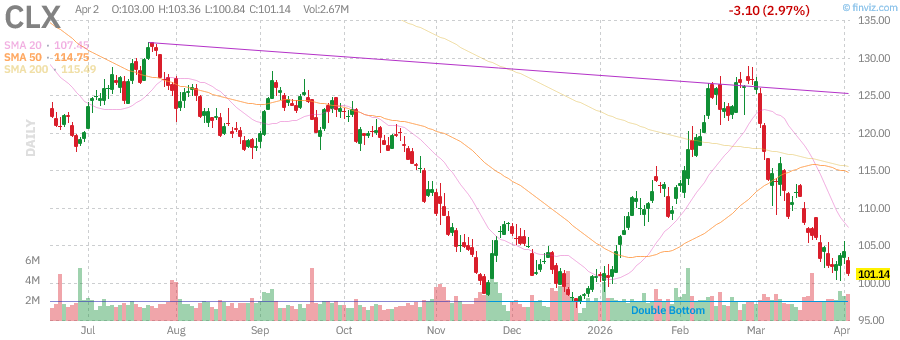

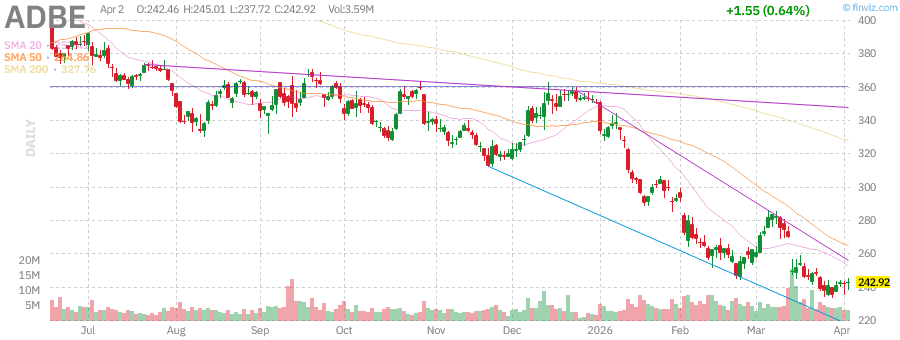

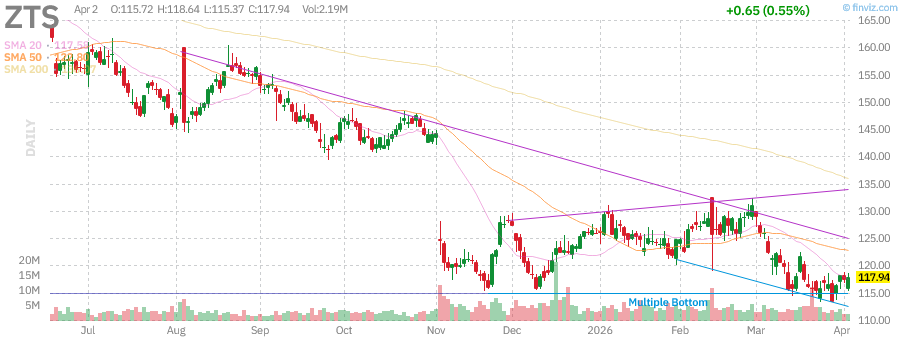

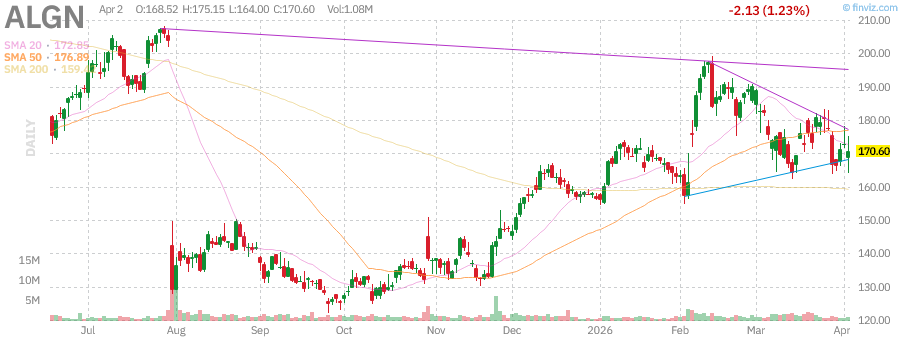

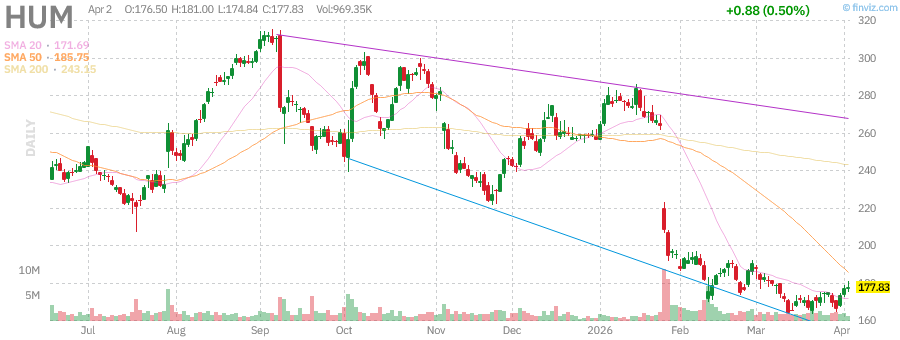

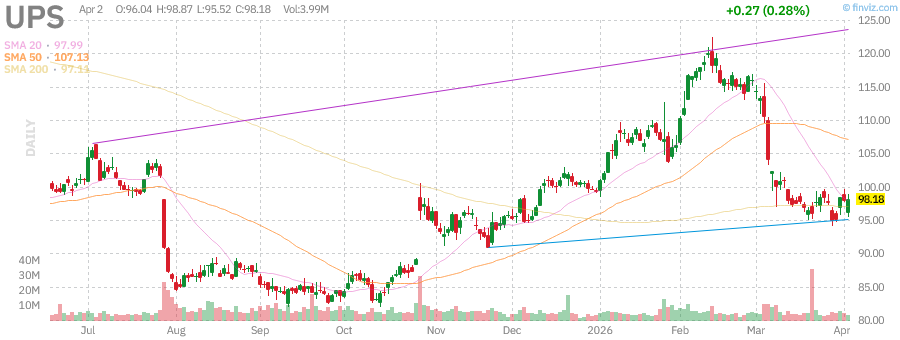

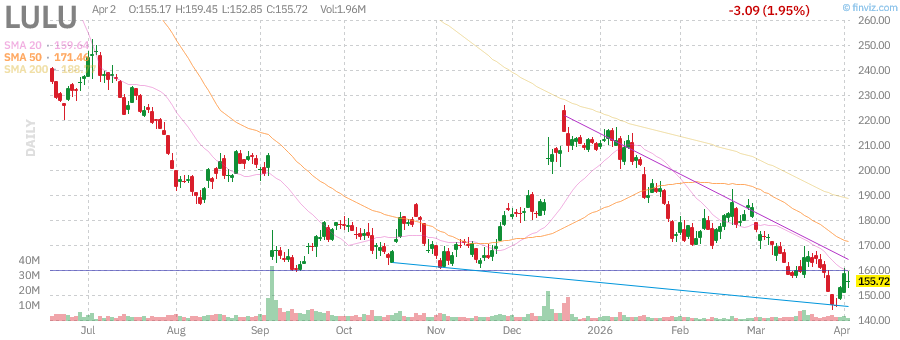

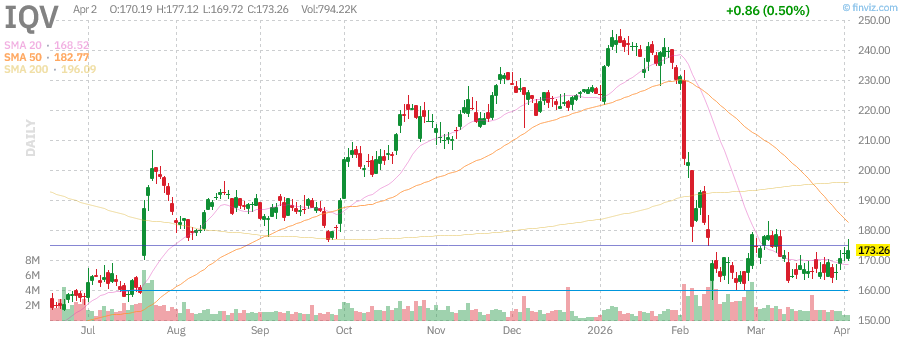

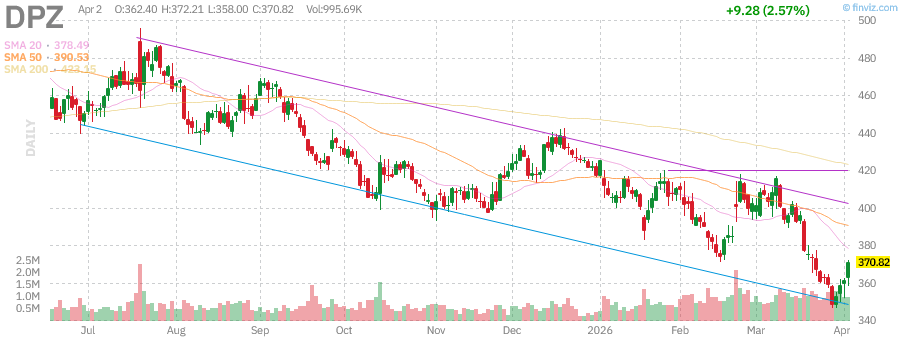

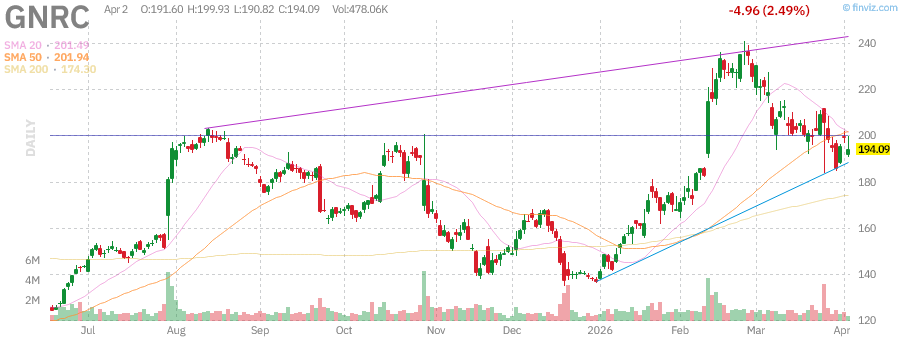

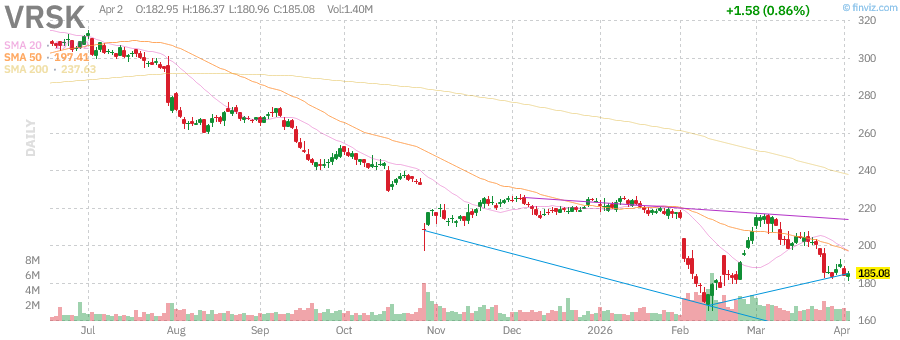

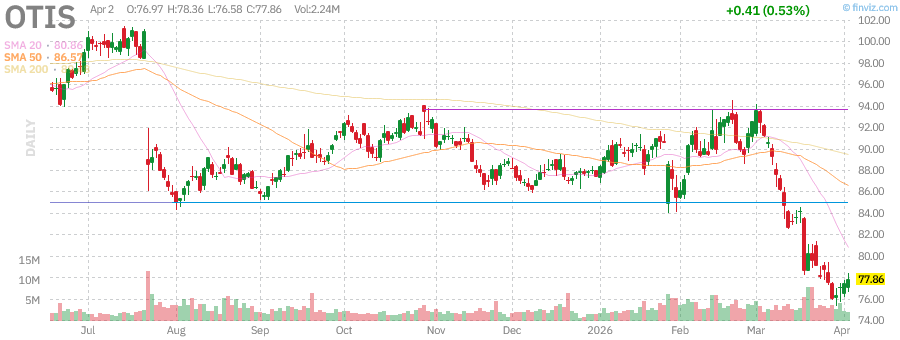

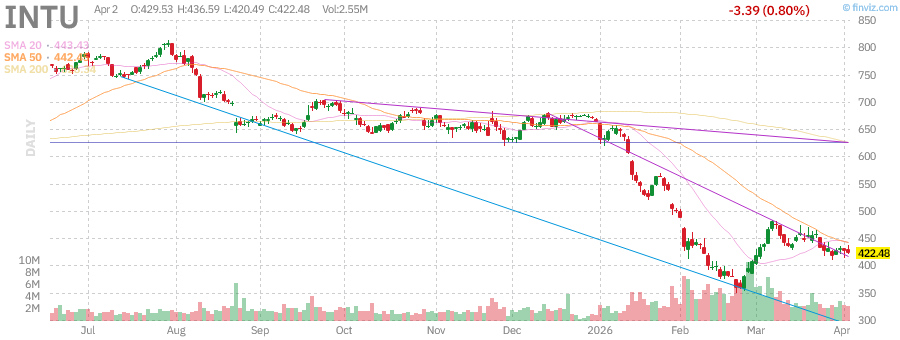

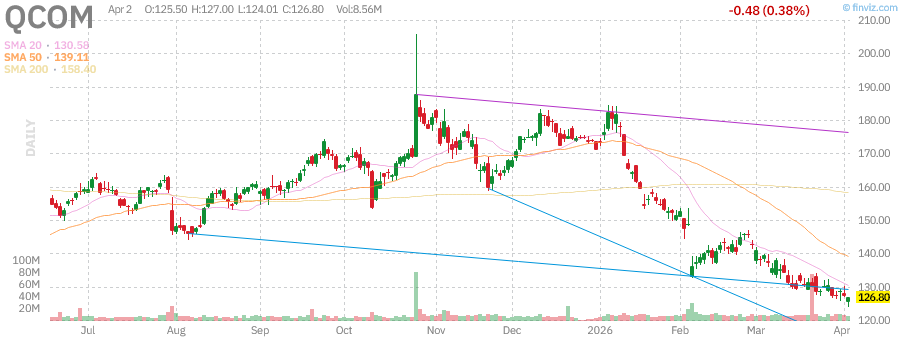

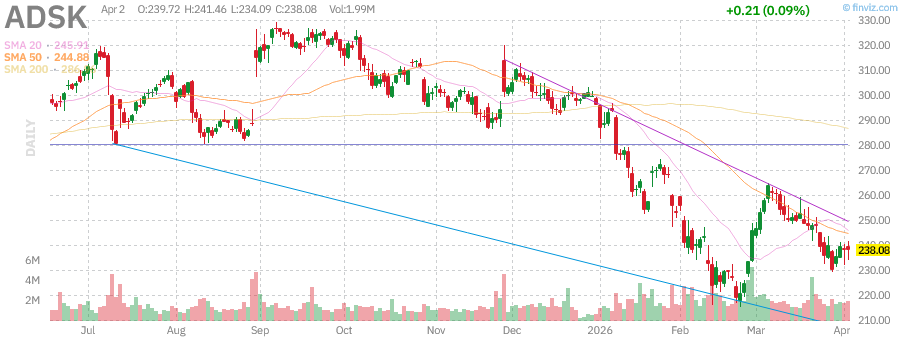

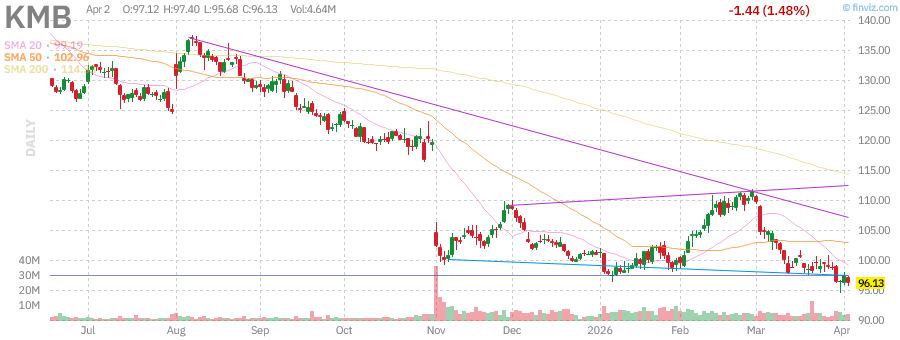

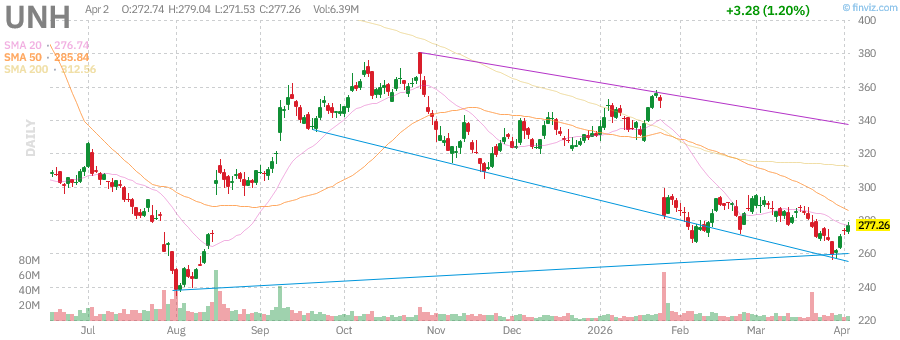

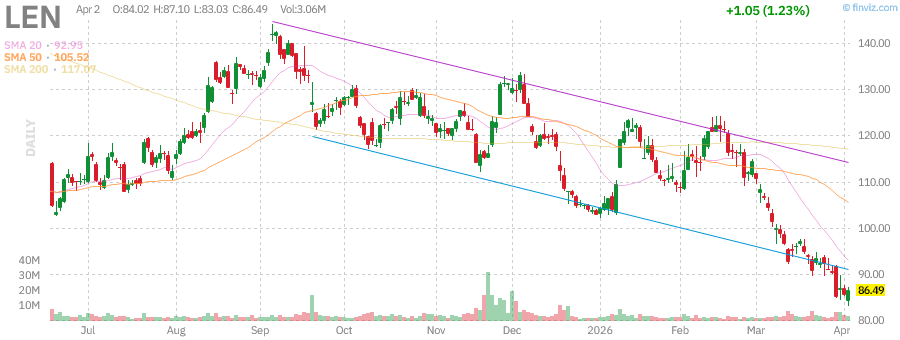

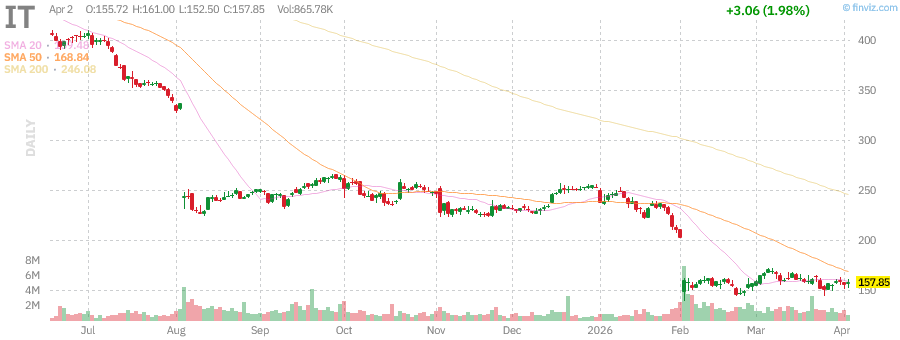

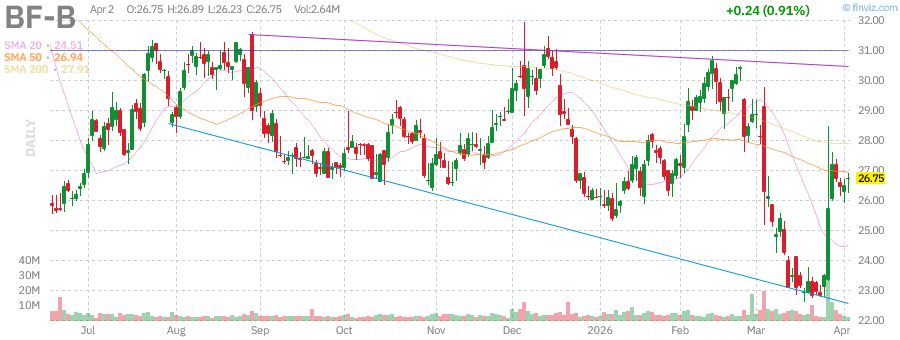

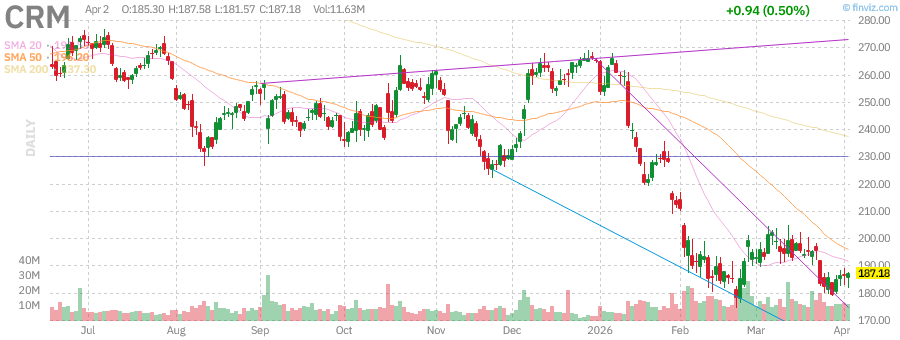

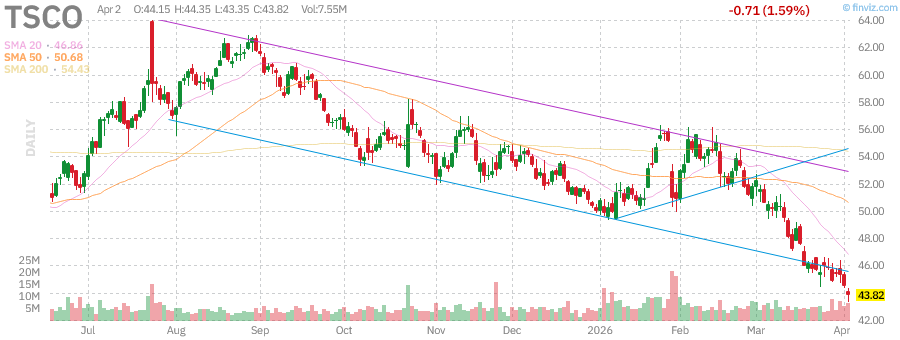

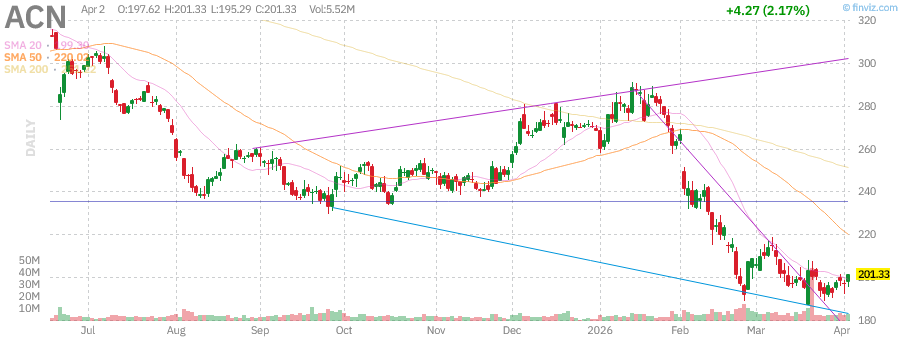

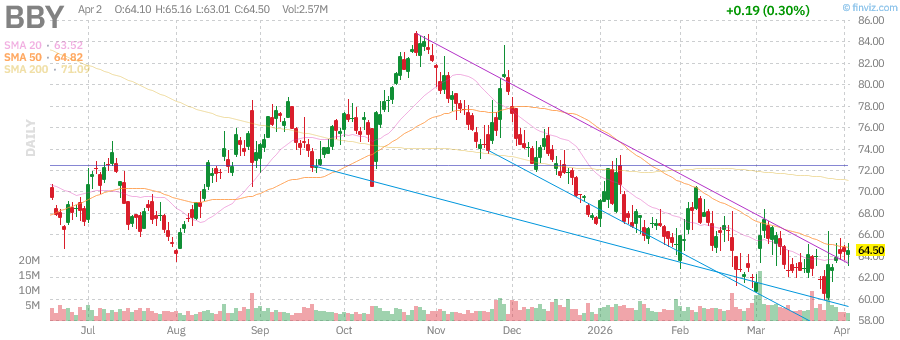

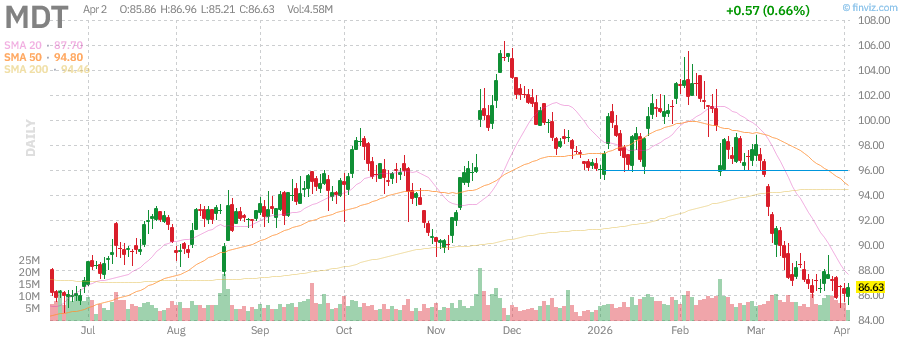

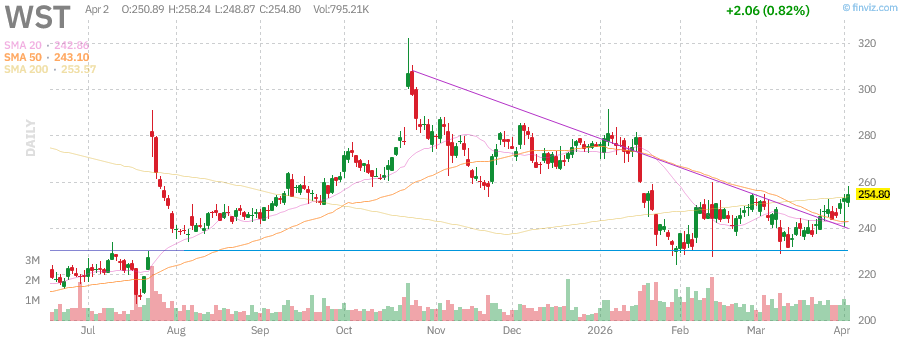

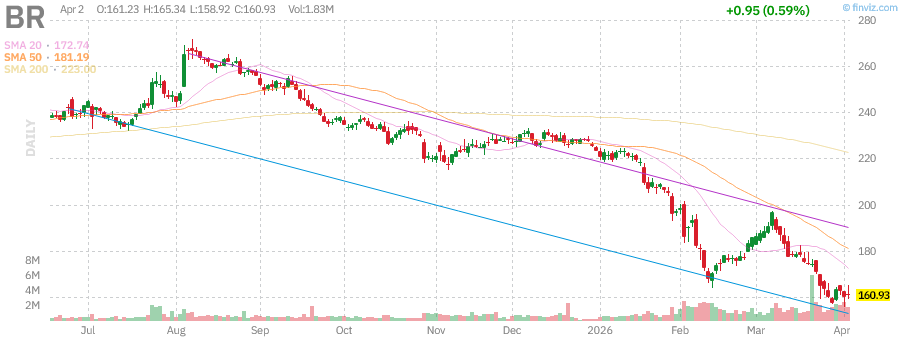

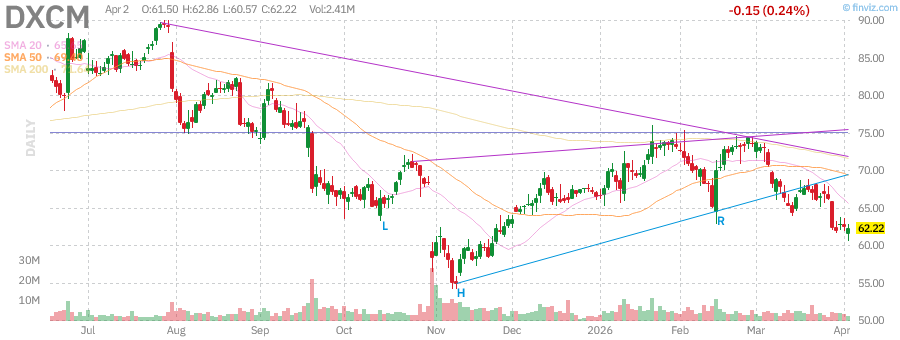

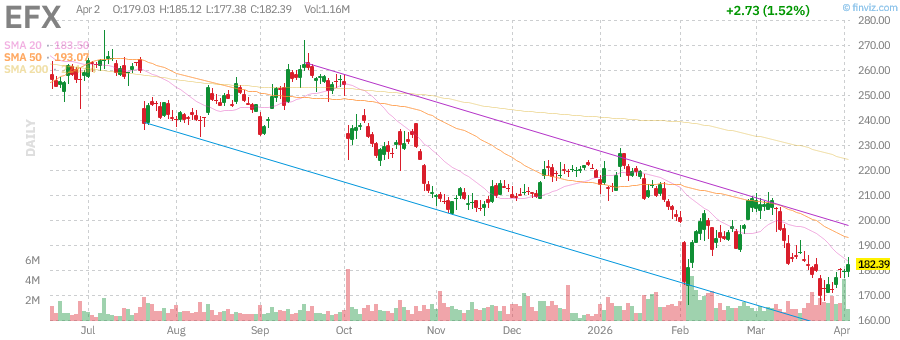

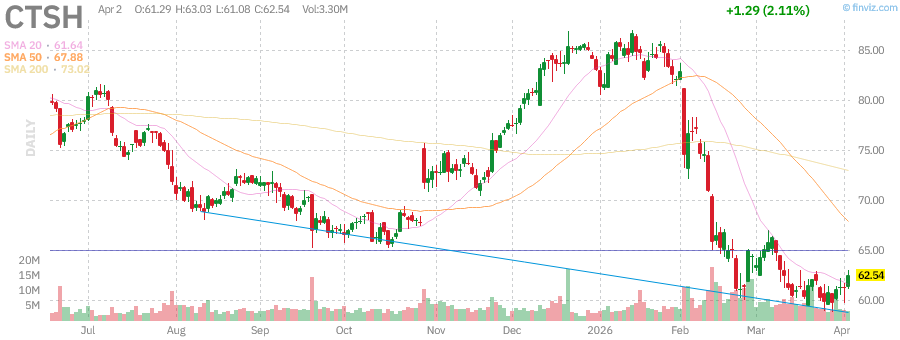

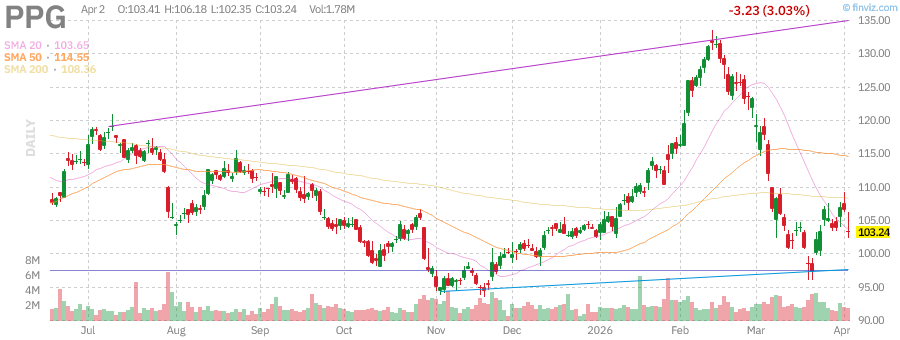

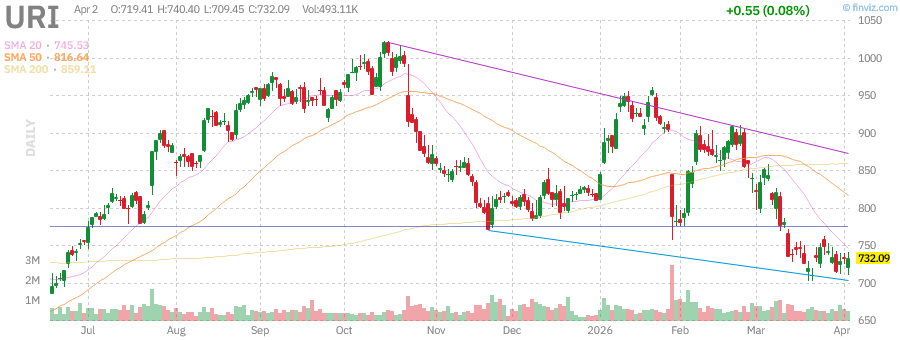

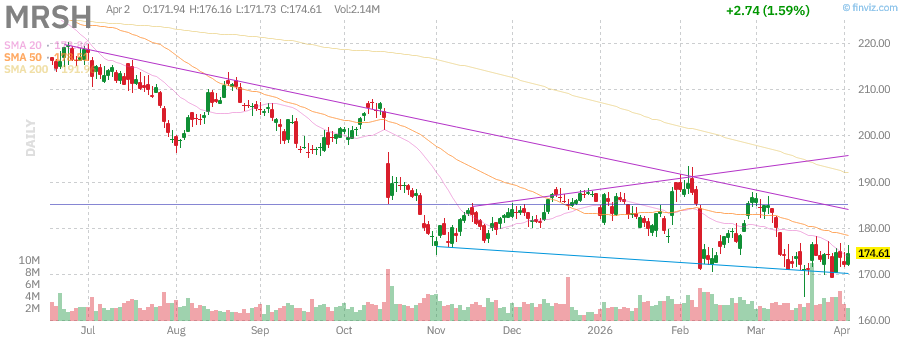

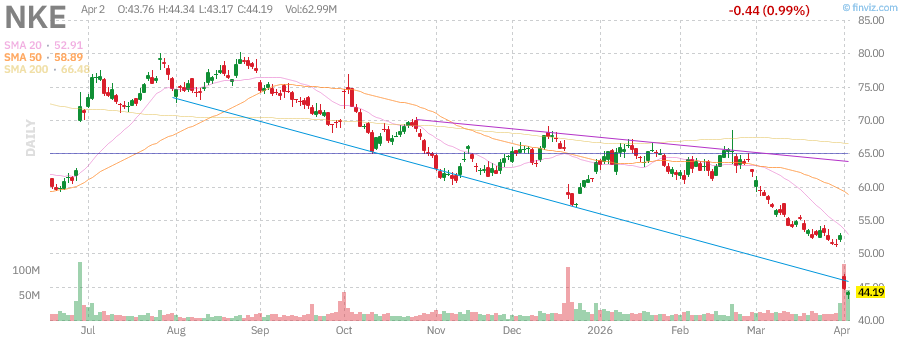

In [ ]:
# --- chart printing ---
from pathlib import Path
from IPython.display import Image, display

output_dir = Path('asset')
output_dir.mkdir(parents=True, exist_ok=True)

failed_chart_tickers = []

for ticker in df.symbol.dropna().unique():
    try:
        stock_obj = finvizfinance(ticker)
        stock_obj.ticker_charts(out_dir=str(output_dir))

        candidate_paths = [
            output_dir / f'{ticker}.jpg',
            output_dir / f'{ticker}.jpeg',
            Path(f'{ticker}.jpg'),
            Path(f'{ticker}.jpeg'),
        ]
        image_path = next((p for p in candidate_paths if p.exists()), None)

        if image_path is not None:
            display(Image(filename=str(image_path)))
        else:
            failed_chart_tickers.append(ticker)
    except Exception:
        failed_chart_tickers.append(ticker)

if failed_chart_tickers:
    print('Chart image not available for:')
    print(failed_chart_tickers)